In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage
import operator

load_dotenv()

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
generator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluater_llm=ChatOpenAI(model="gpt-4o")
optimizer_llm=ChatOpenAI(model="gpt-4o-mini")

In [4]:
from pydantic import BaseModel
class EvaluationSchema(BaseModel):
    evaluation:Literal["approved","needs_improvement"]=Field(...,description="Final evaluation result.")
    feedback:str=Field(...,description="Feedback for the tweet")

In [5]:



class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int
    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]


In [6]:
def generate_post(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer"),
        HumanMessage(
            content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day English
        """
        ),
    ]
    result = generator_llm.invoke(messages).content
    return {"tweet": result,"tweet_history":[result]}


def evaluation(state: TweetState):
    messages = [
        SystemMessage(
            content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
        ),
        HumanMessage(
            content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality - Is this fresh, or have you seen it a hundred times before?
        2. Humor - Did it genuinely make you smile, laugh, or chuckle?
        3. Punchiness - Is it short, sharp, and scroll-stopping?
        4. Virality Potential - Would people retweet or share it?
        5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"
        - feedback: One paragraph explaining the strengths and weaknesses
        """
        ),
    ]
    strucutred_evaluater_llm=evaluater_llm.with_structured_output(EvaluationSchema)
    result = strucutred_evaluater_llm.invoke(messages)
    print(result)
    return {"evaluation": result.evaluation, "feedback": result.feedback,"feedback_history":[result.feedback]}


def optimize(state: TweetState):
    messages = [
        SystemMessage(
            content="You punch up tweets for virality and humor based on given feedback."
        ),
        HumanMessage(
            content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
"""
        ),
    ]

    result = optimizer_llm.invoke(messages).content
    return {
        "tweet":result,"iteration":state["iteration"]+1,"tweet_history":[result]
    }

def check_condition(state:TweetState):
    if(state["evaluation"]=="approved" or state["iteration"]>=state["max_iteration"]):
        return "approved"
    else:
        return "needs_improvement"

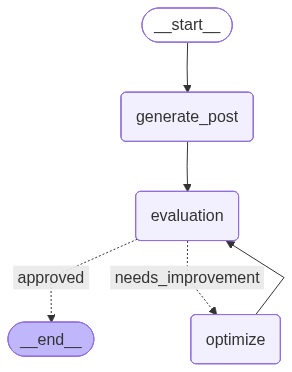

In [7]:
graph=StateGraph(TweetState)
graph.add_node("generate_post", generate_post)
graph.add_node("evaluation", evaluation)
graph.add_node("optimize",optimize)

graph.add_edge(START,"generate_post")
graph.add_edge("generate_post", "evaluation")
graph.add_conditional_edges("evaluation",check_condition,{"approved":END,"needs_improvement":"optimize"})
graph.add_edge("optimize","evaluation")
workflow=graph.compile()
workflow

In [ ]:
initial_state = {
    "topic": "AI Ethics in India",
    "iteration": 0,
    "max_iteration": 5,
}
result=workflow.invoke(initial_state)
print(result)